# Analisis Hasil Eksperimen Feature Combination (no-fairness)

Input: `feature_combination_experiment_summary.csv`


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# FILE INPUT
# =========================
PER_QUERY_FILE = "per_query_metrics.csv"
SUMMARY_FILE = "feature_combination_experiment_summary.csv"

K_VALUES = [10, 20, 30, 40, 45, 50, 60]
K_CANDIDATES = [40, 45, 60]

OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)

per_query = pd.read_csv(PER_QUERY_FILE)
summary = pd.read_csv(SUMMARY_FILE)

per_query.columns = per_query.columns.str.strip()
summary.columns = summary.columns.str.strip()

### 1. Hasil Tiap Query, Skenarion, dan Metrik@K

In [18]:
rows = []

for _, row in per_query.iterrows():
    for k in K_VALUES:
        rows.append({
            "scenario": row["scenario"],
            "query": row["query"],
            "candidate_count": row["candidate_count"],
            "total_relevant": row["total_relevant_in_model"],
            "k": k,
            "precision": row[f"precision@{k}"],
            "recall": row[f"recall@{k}"],
            "f1": row[f"f1@{k}"],
            "ndcg": row[f"ndcg@{k}"],
            "fairness": row[f"fairness@{k}"],
        })

per_query_result = pd.DataFrame(rows)

per_query_result.to_csv(
    OUTPUT_DIR / "01_per_query_metric_at_k.csv",
    index=False,
    encoding="utf-8-sig"
)

per_query_result


,scenario,query,candidate_count,total_relevant,k,precision,recall,f1,ndcg,fairness
0,balanced_no_fairness,kopi khas daerah,70,23,10,1.000000,0.434783,0.606061,1.000000,0.100000
1,balanced_no_fairness,kopi khas daerah,70,23,20,0.750000,0.652174,0.697674,0.831099,0.550000
2,balanced_no_fairness,kopi khas daerah,70,23,30,0.533333,0.695652,0.603774,0.784029,0.700000
3,balanced_no_fairness,kopi khas daerah,70,23,40,0.450000,0.782609,0.571429,0.835350,0.775000
4,balanced_no_fairness,kopi khas daerah,70,23,45,0.400000,0.782609,0.529412,0.835350,0.800000
...,...,...,...,...,...,...,...,...,...,...
1395,value_dominant_no_fairness,tas ransel laptop,70,51,30,1.000000,0.588235,0.740741,1.000000,0.633333
1396,value_dominant_no_fairness,tas ransel laptop,70,51,40,0.950000,0.745098,0.835165,0.964970,0.650000
1397,value_dominant_no_fairness,tas ransel laptop,70,51,45,0.911111,0.803922,0.854167,0.937216,0.644444
1398,value_dominant_no_fairness,tas ransel laptop,70,51,50,0.900000,0.882353,0.891089,0.927883,0.620000


### 2. Rata-rata Metrik Tiap Skenario dan K

In [20]:
summary_rows = []

for _, row in summary.iterrows():
    for k in K_VALUES:
        summary_rows.append({
            "scenario": row["scenario"],
            "k": k,
            "mean_precision": row[f"mean_precision@{k}"],
            "mean_recall": row[f"mean_recall@{k}"],
            "mean_f1": row[f"mean_f1@{k}"],
            "mean_ndcg": row[f"mean_ndcg@{k}"],
            "mean_fairness": row[f"mean_fairness@{k}"],
        })

summary_source_model_k = pd.DataFrame(summary_rows)

summary_model_k = (
    summary_source_model_k
    .groupby(["scenario", "k"], as_index=False)
    .agg(
        avg_precision=("mean_precision", "mean"),
        avg_recall=("mean_recall", "mean"),
        avg_f1=("mean_f1", "mean"),
        avg_ndcg=("mean_ndcg", "mean"),
        avg_fairness=("mean_fairness", "mean"),
    )
)

summary_model_k.to_csv(
    OUTPUT_DIR / "02_summary_model_k.csv",
    index=False,
    encoding="utf-8-sig"
)

summary_model_k


,scenario,k,avg_precision,avg_recall,avg_f1,avg_ndcg,avg_fairness
0,balanced_no_fairness,10,0.896000,0.182415,0.297755,0.878171,0.414000
1,balanced_no_fairness,20,0.886000,0.355013,0.495517,0.864293,0.479000
2,balanced_no_fairness,30,0.854000,0.500473,0.617060,0.851728,0.507333
3,balanced_no_fairness,40,0.834000,0.643409,0.710700,0.856709,0.524000
4,balanced_no_fairness,45,0.824889,0.712453,0.748408,0.866828,0.535556
5,balanced_no_fairness,50,0.808000,0.770301,0.772545,0.873245,0.542800
6,balanced_no_fairness,60,0.781333,0.886447,0.814290,0.899117,0.560333
7,popularity_dominant_no_fairness,10,0.836000,0.168547,0.275612,0.774166,0.352000
8,popularity_dominant_no_fairness,20,0.834000,0.330593,0.463089,0.774638,0.411000
9,popularity_dominant_no_fairness,30,0.811333,0.473962,0.585010,0.777023,0.455333


### 3. Skenario Terbaik + Visualisasi

In [21]:
model_metric_per_k_wide = summary_model_k.pivot_table(
    index="scenario",
    columns="k",
    values=[
        "avg_precision",
        "avg_recall",
        "avg_f1",
        "avg_ndcg",
        "avg_fairness"
    ],
    aggfunc="first"
)

model_metric_per_k_wide.columns = [
    f"{metric.replace('avg_', '')}@{k}"
    for metric, k in model_metric_per_k_wide.columns
]

model_metric_per_k_wide = model_metric_per_k_wide.reset_index()

model_metric_per_k_wide.to_csv(
    OUTPUT_DIR / "03_model_metric_per_k_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

model_metric_per_k_wide


,scenario,f1@10,f1@20,f1@30,f1@40,f1@45,f1@50,f1@60,fairness@10,fairness@20,...,precision@45,precision@50,precision@60,recall@10,recall@20,recall@30,recall@40,recall@45,recall@50,recall@60
0,balanced_no_fairness,0.297755,0.495517,0.617060,0.710700,0.748408,0.772545,0.814290,0.414,0.479,...,0.824889,0.8080,0.781333,0.182415,0.355013,0.500473,0.643409,0.712453,0.770301,0.886447
1,popularity_dominant_no_fairness,0.275612,0.463089,0.585010,0.679875,0.717566,0.753274,0.803229,0.352,0.411,...,0.792000,0.7880,0.771000,0.168547,0.330593,0.473962,0.615856,0.682303,0.751130,0.873875
2,relevance_dominant_no_fairness,0.321512,0.508479,0.634808,0.730422,0.771186,0.794604,0.829282,0.500,0.521,...,0.849333,0.8304,0.795000,0.197258,0.364252,0.515688,0.661016,0.734227,0.792857,0.903849
3,value_dominant_no_fairness,0.284201,0.475950,0.607113,0.698820,0.736634,0.768523,0.811459,0.444,0.487,...,0.812000,0.8032,0.778667,0.173725,0.340544,0.492226,0.632855,0.701299,0.767147,0.883165


In [22]:
# =========================
# SKENARIO TERBAIK PER METRIK DAN PER K
# =========================

best_rows = []

metrics = {
    "precision": "avg_precision",
    "recall": "avg_recall",
    "f1": "avg_f1",
    "ndcg": "avg_ndcg",
    "fairness": "avg_fairness"
}

for metric_name, metric_col in metrics.items():
    for k in K_VALUES:

        temp = summary_model_k[summary_model_k["k"] == k].copy()
        best = temp.sort_values(metric_col, ascending=False).iloc[0]

        best_rows.append({
            "metric": metric_name,
            "k": k,
            "best_scenario": best["scenario"],
            "best_score": best[metric_col]
        })

best_model_per_metric_k = pd.DataFrame(best_rows)

best_model_per_metric_k.to_csv(
    OUTPUT_DIR / "03_best_model_per_metric_k.csv",
    index=False,
    encoding="utf-8-sig"
)

best_model_per_metric_k


,metric,k,best_scenario,best_score
0,precision,10,relevance_dominant_no_fairness,0.960000
1,precision,20,relevance_dominant_no_fairness,0.909000
2,precision,30,relevance_dominant_no_fairness,0.876667
3,precision,40,relevance_dominant_no_fairness,0.856500
4,precision,45,relevance_dominant_no_fairness,0.849333
5,precision,50,relevance_dominant_no_fairness,0.830400
6,precision,60,relevance_dominant_no_fairness,0.795000
7,recall,10,relevance_dominant_no_fairness,0.197258
8,recall,20,relevance_dominant_no_fairness,0.364252
9,recall,30,relevance_dominant_no_fairness,0.515688


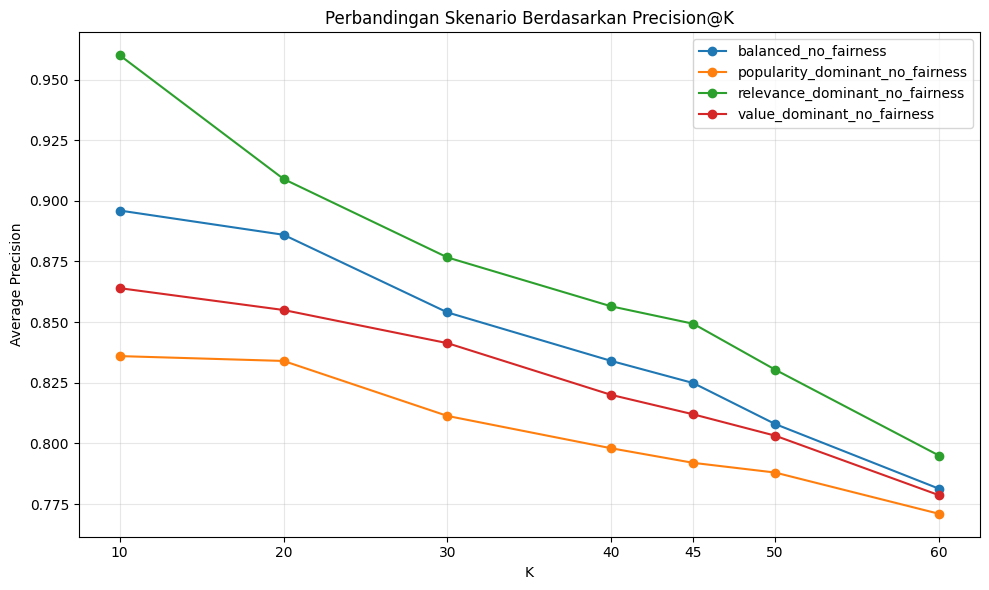

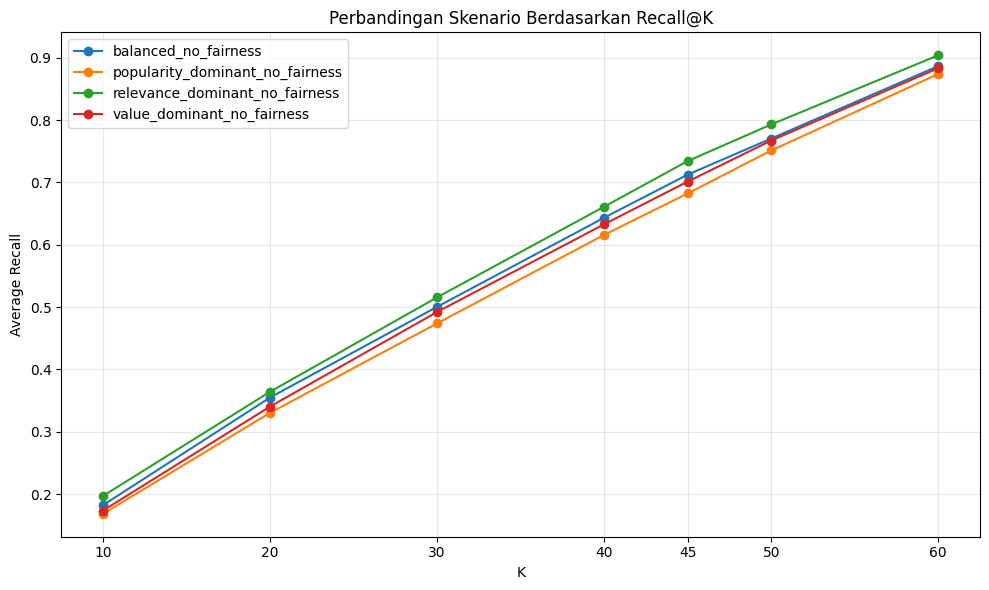

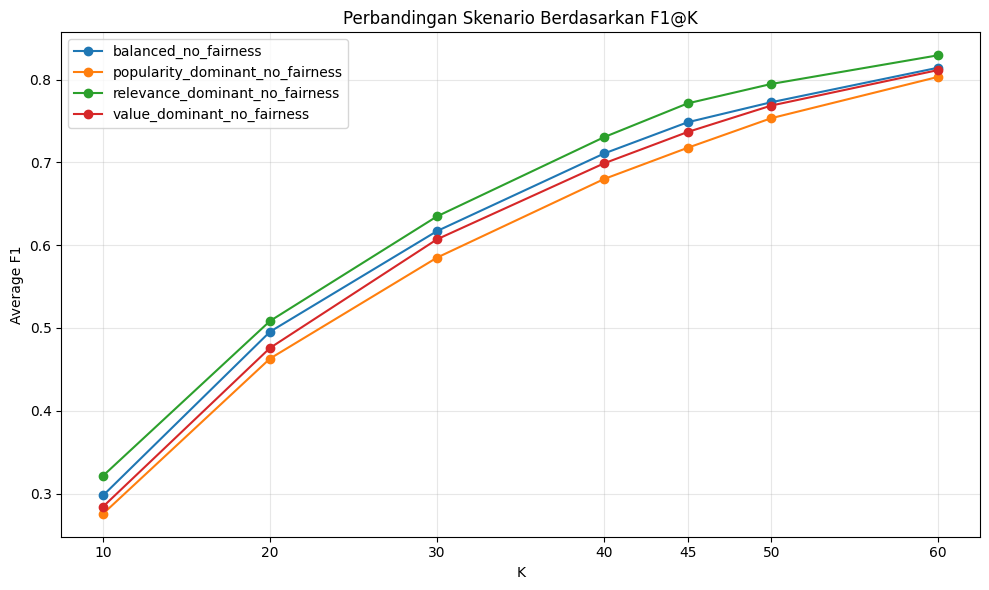

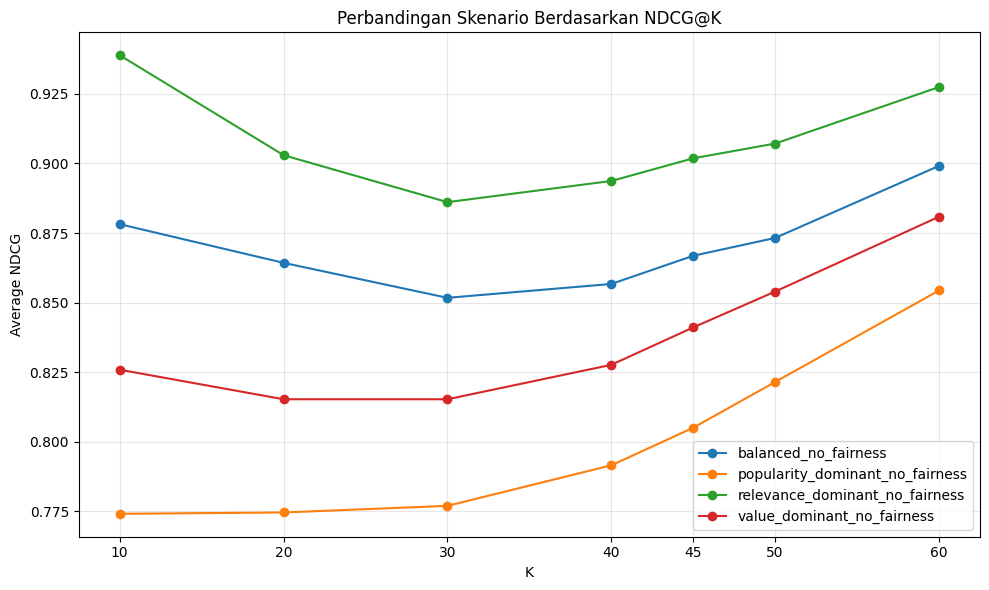

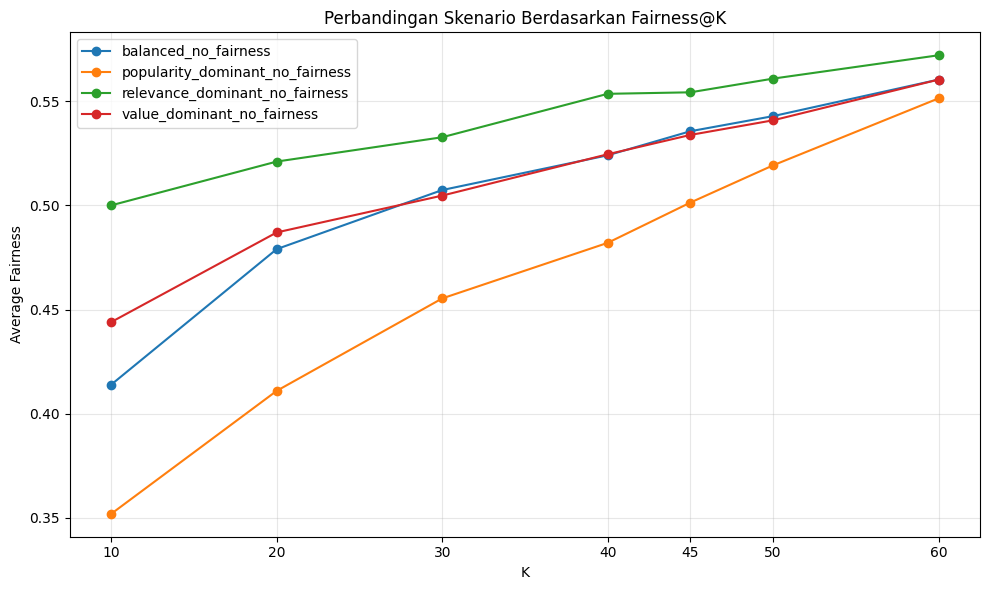

In [23]:
# =========================
# VISUALISASI SEMUA METRIK PER K
# =========================

metrics_to_plot = {
    "avg_precision": {
        "title": "Perbandingan Skenario Berdasarkan Precision@K",
        "ylabel": "Average Precision",
        "filename": "03_scenario_comparison_precision_per_k.png"
    },
    "avg_recall": {
        "title": "Perbandingan Skenario Berdasarkan Recall@K",
        "ylabel": "Average Recall",
        "filename": "03_scenario_comparison_recall_per_k.png"
    },
    "avg_f1": {
        "title": "Perbandingan Skenario Berdasarkan F1@K",
        "ylabel": "Average F1",
        "filename": "03_scenario_comparison_f1_per_k.png"
    },
    "avg_ndcg": {
        "title": "Perbandingan Skenario Berdasarkan NDCG@K",
        "ylabel": "Average NDCG",
        "filename": "03_scenario_comparison_ndcg_per_k.png"
    },
    "avg_fairness": {
        "title": "Perbandingan Skenario Berdasarkan Fairness@K",
        "ylabel": "Average Fairness",
        "filename": "03_scenario_comparison_fairness_per_k.png"
    }
}

for metric_col, config in metrics_to_plot.items():

    plt.figure(figsize=(10, 6))

    for scenario in summary_model_k["scenario"].unique():
        data = summary_model_k[summary_model_k["scenario"] == scenario].sort_values("k")

        plt.plot(
            data["k"],
            data[metric_col],
            marker="o",
            label=scenario
        )

    plt.title(config["title"])
    plt.xlabel("K")
    plt.ylabel(config["ylabel"])
    plt.xticks(K_VALUES)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(OUTPUT_DIR / config["filename"], dpi=200)
    plt.show()


### 4. K Terbaik di antara 40, 45, dan 60 + Visualisasi

In [24]:
# =========================
# K TERBAIK BERDASARKAN F1
# =========================

k_best = (
    summary_model_k[summary_model_k["k"].isin(K_CANDIDATES)]
    .groupby("k", as_index=False)
    .agg(
        avg_precision=("avg_precision", "mean"),
        avg_recall=("avg_recall", "mean"),
        avg_f1=("avg_f1", "mean"),
        avg_ndcg=("avg_ndcg", "mean"),
        avg_fairness=("avg_fairness", "mean"),
    )
    .sort_values("avg_f1", ascending=False)
)

k_best.to_csv(
    OUTPUT_DIR / "04_k_best_40_45_60.csv",
    index=False,
    encoding="utf-8-sig"
)

print("K terbaik berdasarkan F1:")
print(int(k_best.iloc[0]["k"]))
print("Nilai F1:", k_best.iloc[0]["avg_f1"])

k_best


K terbaik berdasarkan F1:
60
Nilai F1: 0.8145648774083621


,k,avg_precision,avg_recall,avg_f1,avg_ndcg,avg_fairness
2,60,0.781500,0.886834,0.814565,0.890442,0.561000
1,45,0.819556,0.707571,0.743448,0.853713,0.531222
0,40,0.827125,0.638284,0.704954,0.842412,0.521000


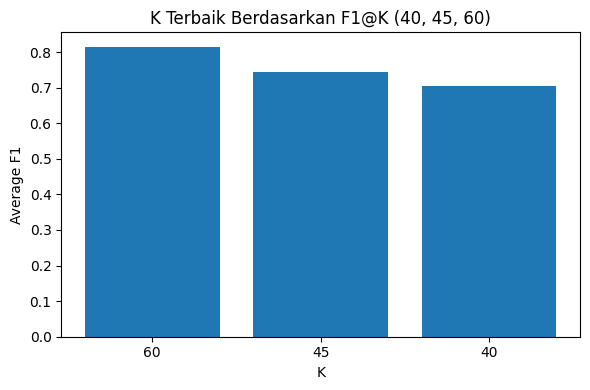

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    k_best["k"].astype(str),
    k_best["avg_f1"]
)

plt.title("K Terbaik Berdasarkan F1@K (40, 45, 60)")
plt.xlabel("K")
plt.ylabel("Average F1")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_k_best_f1_visualization.png", dpi=200)
plt.show()

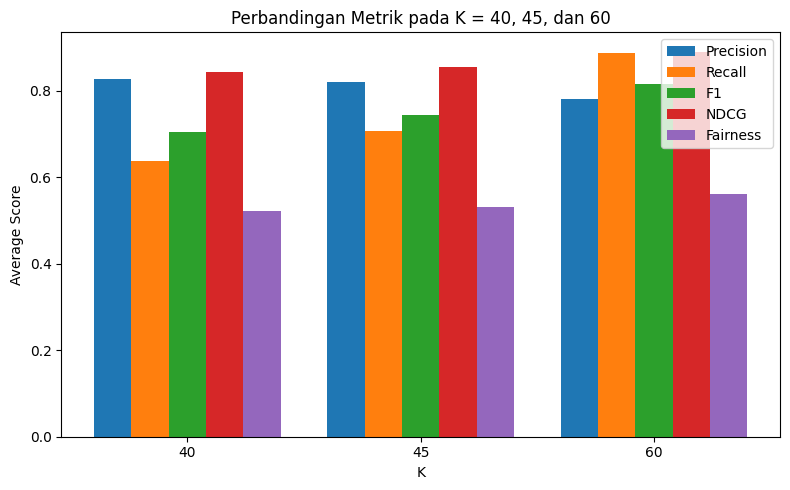

In [27]:
# =========================
# VISUALISASI K TERBAIK
# GROUPED BAR: SETIAP K MENAMPILKAN SEMUA METRIK
# =========================

plot_df = k_best.sort_values("k").copy()

x = np.arange(len(plot_df["k"]))
width = 0.16

plt.figure(figsize=(8, 5))

plt.bar(
    x - 2 * width,
    plot_df["avg_precision"],
    width,
    label="Precision"
)

plt.bar(
    x - width,
    plot_df["avg_recall"],
    width,
    label="Recall"
)

plt.bar(
    x,
    plot_df["avg_f1"],
    width,
    label="F1"
)

plt.bar(
    x + width,
    plot_df["avg_ndcg"],
    width,
    label="NDCG"
)

plt.bar(
    x + 2 * width,
    plot_df["avg_fairness"],
    width,
    label="Fairness"
)

plt.title("Perbandingan Metrik pada K = 40, 45, dan 60")
plt.xlabel("K")
plt.ylabel("Average Score")
plt.xticks(x, plot_df["k"].astype(str))
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_k_best_grouped_metrics.png", dpi=200)
plt.show()
